In [1]:
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('USMA1Q-Methodes-Numeriques'):
        !git clone https://github.com/nickcollins-craft/USMA1Q-Methodes-Numeriques.git
        os.chdir('USMA1Q-Methodes-Numeriques/seance_6')
    else:
        os.chdir('USMA1Q-Methodes-Numeriques')
        !git pull
        os.chdir('seance_6')

# USMA1Q — Méthodes Numériques
## Exercices Séance 6 — Interpolation & Recherche des racines
### Solutions

## Exercice 1 — Interpolation de la conductivité thermique

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 1. Chargement des données
data = np.loadtxt('conductivite_thermique.csv', delimiter=',', skiprows=1)
T_data = data[:, 0]   # °C
k_data = data[:, 1]   # W/(m·K)

print('Températures (°C) :', T_data)
print('Conductivités (W/(m·K)) :', k_data)

Températures (°C) : [ 20.  75. 150. 250. 375. 475. 550. 650. 780. 900.]
Conductivités (W/(m·K)) : [14.  14.3 14.8 15.8 17.5 19.  20.1 21.  21.5 21.9]


In [3]:
# 2 & 3. Grille fine, interpolation linéaire et spline cubique
T_fin = np.linspace(T_data.min(), T_data.max(), 300)
k_lin = np.interp(T_fin, T_data, k_data)

cs = CubicSpline(T_data, k_data)
k_spl = cs(T_fin)

print('k à 400 °C (linéaire) :', round(np.interp(400, T_data, k_data), 3), 'W/(m·K)')
print('k à 400 °C (spline)  :', round(float(cs(400)), 3), 'W/(m·K)')

k à 400 °C (linéaire) : 17.875 W/(m·K)
k à 400 °C (spline)  : 17.867 W/(m·K)


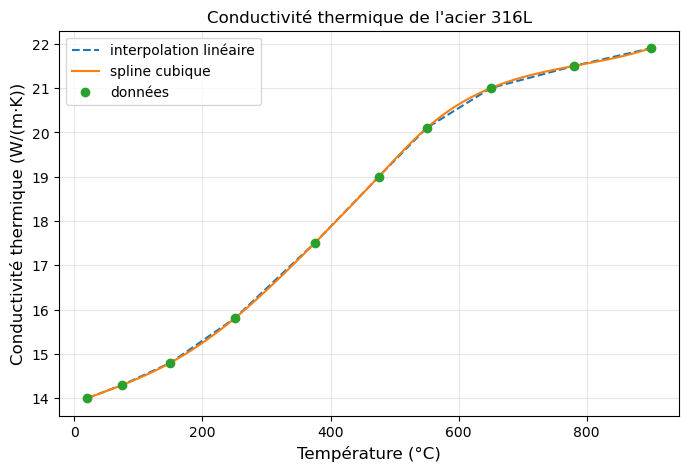

In [4]:
# 4. Tracé
plt.figure(figsize=(8, 5))
plt.plot(T_fin, k_lin, '--', label='interpolation linéaire')
plt.plot(T_fin, k_spl, '-',  label='spline cubique')
plt.plot(T_data, k_data, 'o', label='données')
plt.xlabel('Température (°C)', fontsize=12)
plt.ylabel('Conductivité thermique (W/(m·K))', fontsize=12)
plt.title('Conductivité thermique de l\'acier 316L')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Variation maximale de k à T = 482.1 °C
dk/dT max = 0.01551 W/(m·K²)


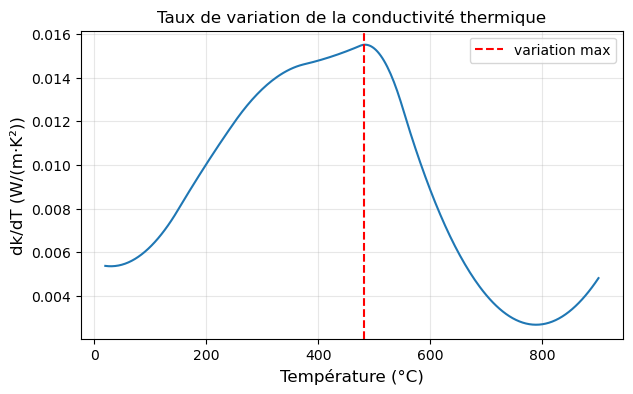

In [5]:
# 5. Dérivée du spline
dk_dT = cs(T_fin, nu=1)
T_max_var = T_fin[np.argmax(np.abs(dk_dT))]

print('Variation maximale de k à T =', round(T_max_var, 1), '°C')
print('dk/dT max =', round(float(cs(T_max_var, nu=1)), 5), 'W/(m·K²)')

plt.figure(figsize=(7, 4))
plt.plot(T_fin, dk_dT, '-')
plt.axvline(T_max_var, color='r', ls='--', label='variation max')
plt.xlabel('Température (°C)', fontsize=12)
plt.ylabel('dk/dT (W/(m·K²))', fontsize=12)
plt.title('Taux de variation de la conductivité thermique')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# 6. Intégrale
integrale = cs.integrate(100, 700)
"print('Intégrale entre 100 et 700 °C :', round(float(integrale), 2), 'W·°C/(m·K)')"
# Unité : [W/(m·K)] × [°C] = W·°C/(m·K)

"print('Intégrale entre 100 et 700 °C :', round(float(integrale), 2), 'W·°C/(m·K)')"

**Réponse question 6 :** L'unité de $\int k(T)\, dT$ est $[W/(m \cdot K)] \times [K] = W/m$. On peut convertir °C à K directement parce qu'ils sont des transformations linéaires entre eux. Cette intégrale intervient dans le calcul du flux de chaleur total sur un gradient de température.

## Exercice 2 — Cartographie 2D de la dureté

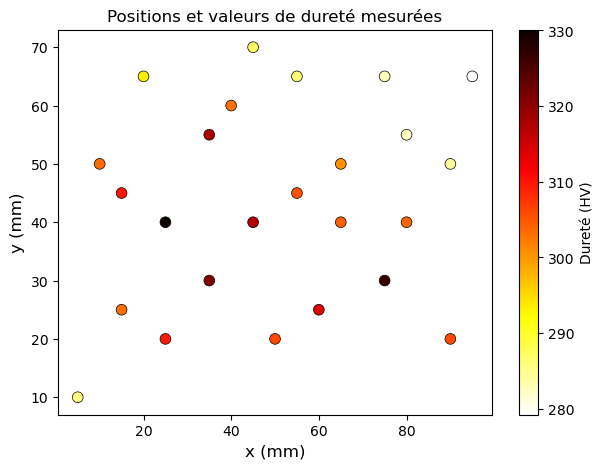

Dureté min : 279.2 HV  à (x, y) = ( 95.0 , 65.0 )
Dureté max : 330.1 HV  à (x, y) = ( 25.0 , 40.0 )


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# 1. Chargement
data_h = np.loadtxt('durete_plaque.csv', delimiter=',', skiprows=1)
x_pts = data_h[:, 0]
y_pts = data_h[:, 1]
hv    = data_h[:, 2]

plt.figure(figsize=(7, 5))
sc = plt.scatter(x_pts, y_pts, c=hv, cmap='hot_r', s=60, edgecolors='k', lw=0.5)
plt.colorbar(sc, label='Dureté (HV)')
plt.xlabel('x (mm)', fontsize=12)
plt.ylabel('y (mm)', fontsize=12)
plt.title('Positions et valeurs de dureté mesurées')
plt.show()

print('Dureté min :', round(hv.min(), 1), 'HV  à (x, y) = (', x_pts[hv.argmin()], ',', y_pts[hv.argmin()], ')')
print('Dureté max :', round(hv.max(), 1), 'HV  à (x, y) = (', x_pts[hv.argmax()], ',', y_pts[hv.argmax()], ')')

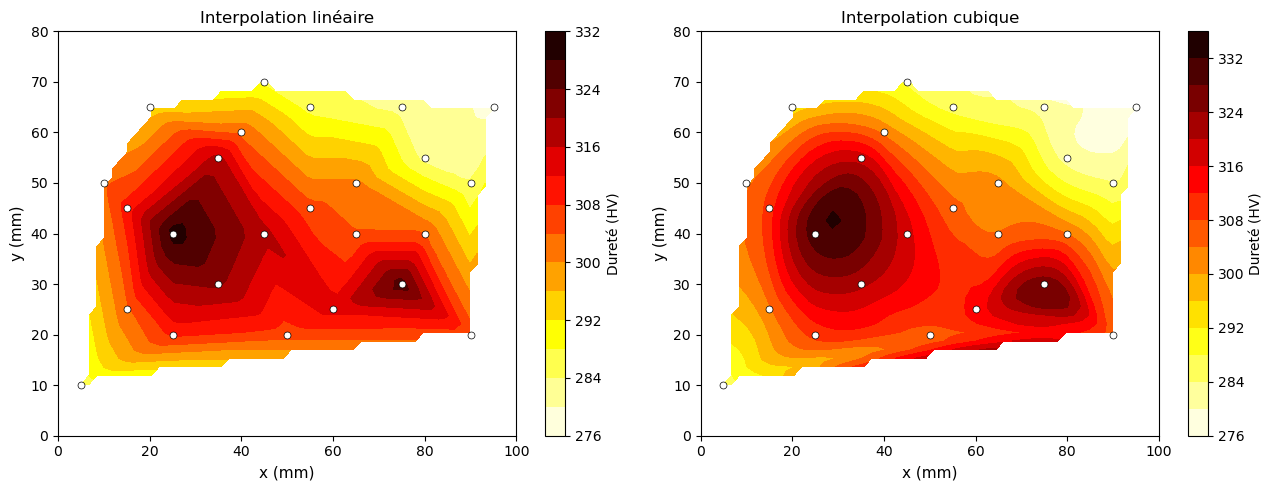

In [8]:
# 2 & 3. Grille régulière et interpolation
xi, yi = np.meshgrid(np.linspace(0, 100, 60), np.linspace(0, 80, 48))
zi_lin = griddata((x_pts, y_pts), hv, (xi, yi), method='linear')
zi_cub = griddata((x_pts, y_pts), hv, (xi, yi), method='cubic')

# 4. Cartes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, z, title in zip(axes, [zi_lin, zi_cub], ['linéaire', 'cubique']):
    cf = ax.contourf(xi, yi, z, levels=15, cmap='hot_r')
    ax.scatter(x_pts, y_pts, c='white', s=25, zorder=5, edgecolors='k', lw=0.5)
    plt.colorbar(cf, ax=ax, label='Dureté (HV)')
    ax.set_xlabel('x (mm)', fontsize=11)
    ax.set_ylabel('y (mm)', fontsize=11)
    ax.set_title('Interpolation ' + title)
plt.tight_layout()
plt.show()

**Réponse question 5 :** Les deux pics de dureté se trouvent autour de (30, 40) mm et (75, 25) mm. Des mesures supplémentaires seraient utiles dans les zones peu couvertes — coins de la plaque et zones entre les deux pics — pour réduire l'incertitude d'interpolation là où le gradient de dureté est le plus fort.

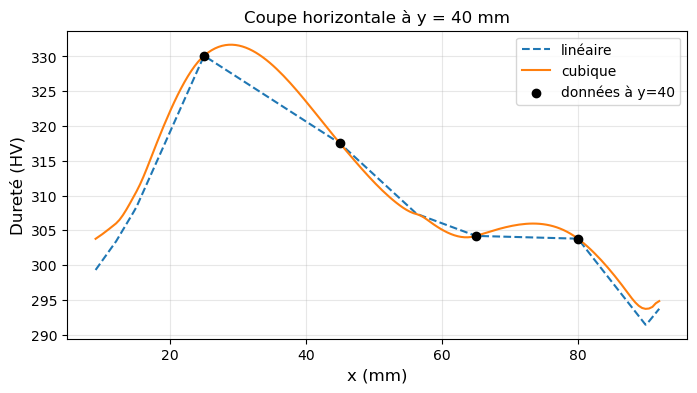

In [9]:
# 6. Bonus — coupe à y = 40 mm
x_coupe = np.linspace(0, 100, 200)
y_coupe = 40 * np.ones_like(x_coupe)
hv_coupe_lin = griddata((x_pts, y_pts), hv, (x_coupe, y_coupe), method='linear')
hv_coupe_cub = griddata((x_pts, y_pts), hv, (x_coupe, y_coupe), method='cubic')

plt.figure(figsize=(8, 4))
plt.plot(x_coupe, hv_coupe_lin, '--', label='linéaire')
plt.plot(x_coupe, hv_coupe_cub, '-',  label='cubique')
pts_y40 = y_pts == 40
if pts_y40.any():
    plt.scatter(x_pts[pts_y40], hv[pts_y40], c='k', zorder=5, label='données à y=40')
plt.xlabel('x (mm)', fontsize=12)
plt.ylabel('Dureté (HV)', fontsize=12)
plt.title('Coupe horizontale à y = 40 mm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Exercice 3 — Recherche des racines scalaires

### 3.1 — Point d'ébullition par Clausius-Clapeyron

In [10]:
import numpy as np
from scipy.optimize import brentq

L     = 40000.0
R     = 8.314
T_ref = 353.0
P_ref = 98000.0
P_atm = 101325.0

def P(T):
    return P_ref * np.exp(-(L / R) * (1.0/T - 1.0/T_ref))

def f(T):
    return P(T) - P_atm

print('Vérification P(353) =', round(P(353), 1), 'Pa')
print('f(340) =', round(f(340), 1))
print('f(370) =', round(f(370), 1))

Vérification P(353) = 98000.0 Pa
f(340) = -43127.3
f(370) = 81985.4


In [11]:
def bisection(f, a, b, tol=1e-8):
    iterations = 0
    while (b - a) / 2 > tol:
        c = (a + b) / 2
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
        iterations += 1
    return (a + b) / 2, iterations

def dP_dT(T):
    return P(T) * L / (R * T**2)

def df_dT(T):
    return dP_dT(T)

def newton(f, df, x0, tol=1e-8, max_iter=50):
    x = x0
    for i in range(1, max_iter + 1):
        x = x - f(x) / df(x)
        if abs(f(x)) < tol:
            return x, i
    return x, max_iter

T_bis, n_bis   = bisection(f, 340.0, 370.0)
T_newt, n_newt = newton(f, df_dT, x0=355.0)
T_brent        = brentq(f, 340.0, 370.0)

print('Méthode       | T_éb (K)  | Nb itérations')
print('--------------|-----------|---------------')
print('Bissection    |', round(T_bis, 5),   '|', n_bis)
print('Newton        |', round(T_newt, 5),  '|', n_newt)
print('brentq        |', round(T_brent, 5), '|  (interne)')

print('T_ébullition =', round(T_brent - 273.15, 2), '°C')

Méthode       | T_éb (K)  | Nb itérations
--------------|-----------|---------------
Bissection    | 353.86629 | 31
Newton        | 353.86629 | 3
brentq        | 353.86629 |  (interne)
T_ébullition = 80.72 °C


### 3.2 — Limite d'élasticité à 0,2 % d'écart

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

data_s = np.loadtxt('courbe_contrainte_deformation.csv', delimiter=',', skiprows=1)
eps_data = data_s[:, 0]
sig_data = data_s[:, 1]

cs_sig = CubicSpline(eps_data, sig_data)

In [13]:
# Module de Young — régression linéaire dans le domaine élastique
masque_elastique = eps_data < 0.0006
coeffs = np.polyfit(eps_data[masque_elastique], sig_data[masque_elastique], 1)
E = coeffs[0]   # pente = E en MPa
print('Module de Young estimé :', round(E / 1000, 1), 'GPa')

# Résiduelle et résolution
def f_offset(eps):
    return float(cs_sig(eps)) - E * (eps - 0.002)

print('f_offset(0.001) =', round(f_offset(0.001), 2))
print('f_offset(0.007) =', round(f_offset(0.007), 2))

eps_02 = brentq(f_offset, 0.001, 0.007)
sig_02 = float(cs_sig(eps_02))
print('Limite d\'élasticité à 0,2 % :', round(sig_02, 1), 'MPa  à ε =', round(eps_02, 5))

Module de Young estimé : 199.9 GPa
f_offset(0.001) = 391.02
f_offset(0.007) = -689.94
Limite d'élasticité à 0,2 % : 280.0 MPa  à ε = 0.0034


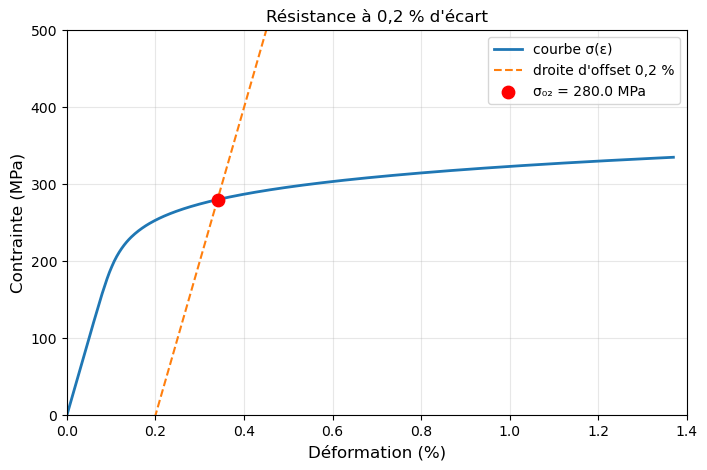

In [14]:
eps_fin = np.linspace(eps_data.min(), eps_data.max(), 500)
sig_fin = cs_sig(eps_fin)
droite_offset = E * (eps_fin - 0.002)

plt.figure(figsize=(8, 5))
plt.plot(eps_fin * 100, sig_fin, '-', lw=2, label='courbe σ(ε)')
plt.plot(eps_fin * 100, droite_offset, '--', label='droite d\'offset 0,2 %')
plt.scatter([eps_02 * 100], [sig_02], c='red', s=80, zorder=5,label='σ₀₂ = %.1f MPa' % sig_02)
plt.xlabel('Déformation (%)', fontsize=12)
plt.ylabel('Contrainte (MPa)', fontsize=12)
plt.title('Résistance à 0,2 % d\'écart')
plt.xlim(0, 1.4)
plt.ylim(0, 500)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Exercice 4 — Analyse d'une courbe de refroidissement

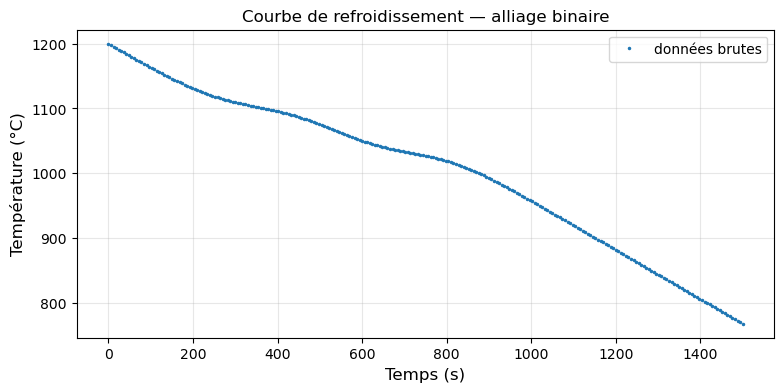

Durée : 1500.0 s — 251 points


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_smoothing_spline
from scipy.optimize import brentq

# 1. Chargement
data_c = np.loadtxt('courbe_refroidissement.csv', delimiter=',', skiprows=1)
t_data = data_c[:, 0]
T_data = data_c[:, 1]

plt.figure(figsize=(9, 4))
plt.plot(t_data, T_data, '.', ms=3, label='données brutes')
plt.xlabel('Temps (s)', fontsize=12)
plt.ylabel('Température (°C)', fontsize=12)
plt.title('Courbe de refroidissement — alliage binaire')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Durée :', round(t_data[-1], 0), 's —', len(t_data), 'points')

In [16]:
# 2. Spline et dérivées
cs_T = make_smoothing_spline(t_data, T_data, lam=10000)

t_fin   = np.linspace(t_data.min(), t_data.max(), 2000)
T_fin   = cs_T(t_fin)
dT_fin  = cs_T(t_fin, nu=1)
d2T_fin = cs_T(t_fin, nu=2)

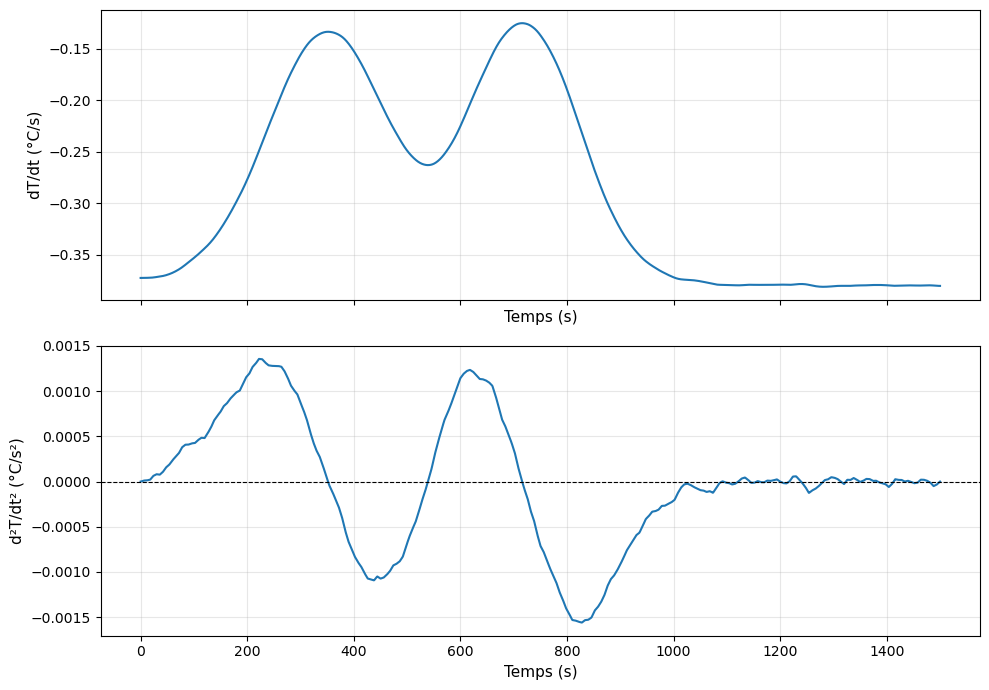

In [17]:
# 3. Tracé des dérivées
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Tracé de dT/dt
axes[0].plot(t_fin, dT_fin, '-', lw=1.5)
axes[0].set_ylabel('dT/dt (°C/s)', fontsize=11)
axes[0].set_xlabel('Temps (s)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Tracé de d²T/dt²
axes[1].plot(t_fin, d2T_fin, '-', lw=1.5)
axes[1].axhline(0, color='k', ls='--', lw=0.8)
axes[1].set_xlabel('Temps (s)', fontsize=11)
axes[1].set_ylabel('d²T/dt² (°C/s²)', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# 4. Détection des zéros de d²T/dt² → temperatures de transformation
def d2T(t):
    return cs_T(t, nu=2)

d2T_vals = d2T(t_fin)
transformations = []
for i in range(len(t_fin) - 1):
    if t_fin[i] >= 100 and t_fin[i] <= 1000:  # limiter la recherche à l'intervalle pertinent
        if d2T_vals[i]*d2T_vals[i + 1] < 0:
            r = brentq(d2T, t_fin[i], t_fin[i + 1])
            transformations.append(r)

print('Temps (s)       :', [round(r, 1) for r in transformations])
print('Températures (°C):', [round(float(cs_T(r)), 1) for r in transformations])

Temps (s)       : [351.6, 539.1, 715.9]
Températures (°C): [1102.5, 1065.5, 1031.3]


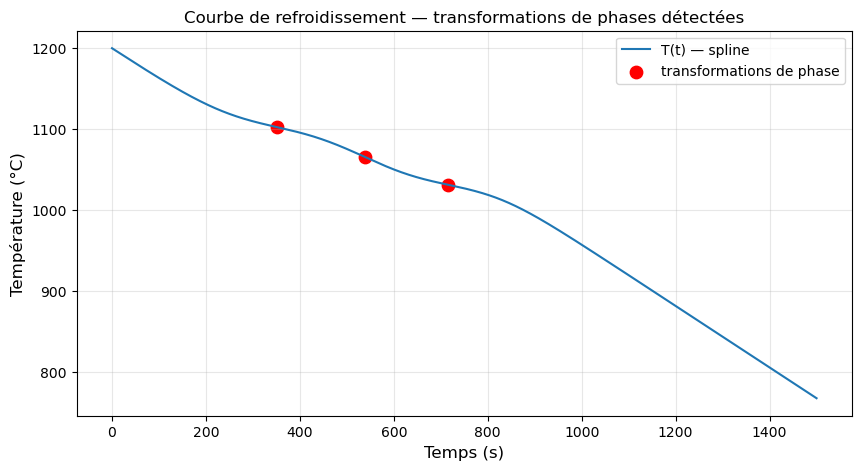

In [19]:
# 5. Tracé final avec transformations de phase
plt.figure(figsize=(10, 5))
plt.plot(t_fin, T_fin, '-', lw=1.5, label='T(t) — spline')
plt.scatter(transformations, [float(cs_T(r)) for r in transformations], c='red', s=80, label='transformations de phase')
plt.xlabel('Temps (s)', fontsize=12)
plt.ylabel('Température (°C)', fontsize=12)
plt.title('Courbe de refroidissement — transformations de phases détectées')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()